In [3]:
import pandas as pd
df = pd.read_csv("DDOS_O.csv")

print(df.shape)

print(df["Label"].isnull().sum())

print(df["Label"].value_counts(dropna=False))

print(df["Label"].unique())

(28811, 79)
0
Label
BENIGN    19810
DDoS       9001
Name: count, dtype: int64
['BENIGN' 'DDoS']


In [4]:
print(df.shape)


print(df["Label"].value_counts(dropna=False))


(28811, 79)
Label
BENIGN    19810
DDoS       9001
Name: count, dtype: int64


In [5]:
print(df["Label"].value_counts())

Label
BENIGN    19810
DDoS       9001
Name: count, dtype: int64


In [6]:
from sklearn.model_selection import train_test_split

X = df.drop("Label", axis=1)
y = df["Label"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [7]:

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

In [8]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(
    max_iter=1000,
    random_state=42
)

lr.fit(X_train_scaled, y_train)

lr_pred = lr.predict(X_test_scaled)

In [9]:
from sklearn.metrics import accuracy_score

lr_acc = accuracy_score(
    y_test,
    lr_pred
)

print(lr_acc)

0.9975707096998091


random forest

In [10]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

In [11]:
rf_acc = accuracy_score(
    y_test,
    rf_pred
)

print(rf_acc)

1.0


In [12]:
results = pd.DataFrame({
    "Model":[
        "Logistic Regression",
        "Random Forest"
    ],
    "Accuracy":[
        lr_acc,
        rf_acc
    ]
})

results

,Model,Accuracy
0,Logistic Regression,0.997571
1,Random Forest,1.000000


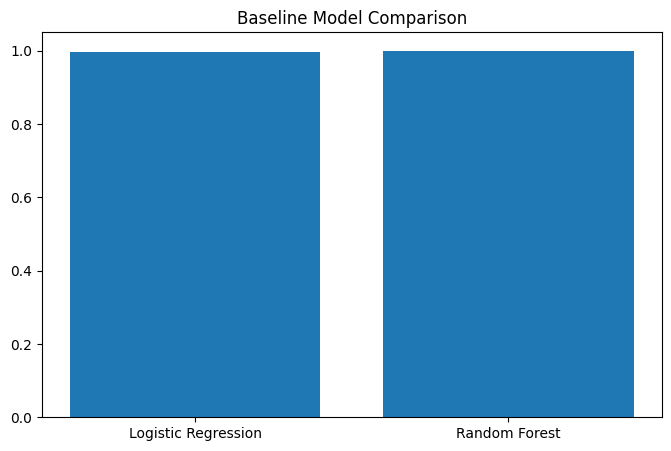

In [13]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.bar(
    results["Model"],
    results["Accuracy"]
)

plt.title(
    "Baseline Model Comparison"
)

plt.show()